In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

In [3]:
from core.semantic_similarity_check.utils import init_random_seed
from core.data_preparation.visualization import *
from core.data_preparation.transformations import *

In [4]:
init_random_seed(316)

In [5]:
data_path = 'data/out'

In [6]:
scored_data = pd.read_csv(f"{data_path}/queries_with_similarity_score.csv", index_col=0)
scored_data.sample(30)

,Prompt,expected_answer,temperature,top_p,completion_tokens,Answer,token_logprobs,finish_reason,_risk,id,hallucination_score,similarity_score
41479,[INST] You are an AI assistant. User will you ...,"Raghav Sood, born on April 16, 1997 in New Del...",0.8,0.95,284,Raghav Sood is an Indian computer science exp...,"[-0.3800466924660596, -0.02004826145306194, -3...",stop,0.135623,41479,0.15000,0.974595
22865,[INST] You are an AI assistant. Provide a deta...,"Yes, the answer is ""you will live with him or ...",0.8,0.95,2,Yes.,"[-0.05463788120857149, -0.7949427167696456]",stop,0.555124,22865,0.02500,0.610333
43881,[INST] You are an AI assistant. User will you ...,"Question: In the context of the passage, what ...",0.8,0.95,32,What event occurred just a few days after the...,"[-0.38518122197789756, -0.4897347097143763, -1...",stop,0.381648,43881,0.25781,0.774798
41707,"[INST] You are a helpful assistant, who always...",The Eagle is a family-friendly coffee shop nea...,0.8,0.95,53,\n The Eagle is a coffee shop. It's...,"[-0.600023668977028, -3.827469507256379, -0.34...",stop,0.290898,41707,0.12345,0.914389
44439,[INST] You are an AI assistant that helps peop...,To calculate the additional miles Kona drove b...,0.0,0.95,308,"\n\n First, let's calculate the total d...","[-0.36806971154570395, -0.20391567908277058, -...",stop,0.059090,44439,0.62500,0.946485
20705,[INST] You are an AI assistant. You will be gi...,Acestea sunt doar valori politice?,0.8,0.95,400,Do they have any real meaning beyond the word...,"[-2.905612579744089, -0.8820306113583808, -1.5...",stop,0.154380,20705,0.85742,0.565495
44156,[INST] You are an AI assistant that follows in...,No I can't,0.8,0.95,5,300 words,"[-3.3074259520393534, -3.3459477314910195, -2....",stop,1.583499,44156,1.00000,0.492212
46208,[INST] You are an AI assistant that follows in...,"In which city does the protagonist, Eric Bisho...",0.8,0.95,368,Manchester for the following movie plot: Thi...,"[-1.571330796449889, -2.2135300355639163, -0.5...",stop,0.019958,46208,0.95000,0.722325
17346,[INST] You are an AI assistant. Provide a deta...,"Based on the given background and situation, P...",0.0,0.95,136,"\n Based on the information provided, i...","[-0.4463551618745845, -0.7856936045660562, -1....",stop,0.101291,17346,0.02500,0.964762
41677,"[INST] You are a helpful assistant, who always...","Well, let's think about when we rub our hands ...",0.0,0.95,24,c). cools water . d). cools the skin\n\nAnswe...,"[-0.01030723112606052, -0.047569215497376416, ...",stop,0.150965,41677,0.12345,0.814281


In [7]:
scored_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68395 entries, 0 to 68394
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Prompt               68395 non-null  object 
 1   expected_answer      68379 non-null  object 
 2   temperature          68395 non-null  float64
 3   top_p                68395 non-null  float64
 4   completion_tokens    68395 non-null  int64  
 5   Answer               68394 non-null  object 
 6   token_logprobs       68395 non-null  object 
 7   finish_reason        68395 non-null  object 
 8   _risk                68395 non-null  float64
 9   id                   68395 non-null  int64  
 10  hallucination_score  68395 non-null  float64
 11  similarity_score     68395 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 6.8+ MB


In [8]:
missing_data = pd.DataFrame({
    "column": scored_data.columns,
    "missing_count": scored_data.isna().sum(),
    "missing_percent": scored_data.isna().mean() * 100
})

missing_data

,column,missing_count,missing_percent
Prompt,Prompt,0,0.000000
expected_answer,expected_answer,16,0.023394
temperature,temperature,0,0.000000
top_p,top_p,0,0.000000
completion_tokens,completion_tokens,0,0.000000
Answer,Answer,1,0.001462
token_logprobs,token_logprobs,0,0.000000
finish_reason,finish_reason,0,0.000000
_risk,_risk,0,0.000000
id,id,0,0.000000


In [9]:
scored_data[scored_data.isna().any(axis=1)]

,Prompt,expected_answer,temperature,top_p,completion_tokens,Answer,token_logprobs,finish_reason,_risk,id,hallucination_score,similarity_score
2572,"question:Detailed Instructions: In this task, ...",NaN,0.0,0.95,860,Hij was naar eigen zeggen ' gedegouteerd ' ove...,"[-2.0007801815582797, -0.22329805241473347, -1...",length,0.013139,2572,0.95000,0.425756
2573,"question:Detailed Instructions: In this task, ...",NaN,0.8,0.95,77,Hij was naar eigen zeggen 'gedegouteerd' over ...,"[-1.989262656575958, -0.21517197640668637, -1....",stop,0.056825,2573,0.95000,0.423163
2574,"question:Detailed Instructions: In this task, ...",NaN,0.8,0.95,1,NaN,[-3.2169819635217585],stop,4.641124,2574,1.00000,1.000000
2575,"question:Detailed Instructions: In this task, ...",NaN,0.8,0.95,31,"Hij, manier, ambtenaren, crisis, parlementaire...","[-1.989262656575958, -0.21517197640668637, -1....",stop,0.235629,2575,0.85234,0.501622
32665,[INST] You are an AI assistant that follows in...,NaN,0.0,0.95,1,None,[-1.4330911934276405],stop,2.067514,32665,0.00000,0.584664
32666,[INST] You are an AI assistant that follows in...,NaN,0.8,0.95,69,\n\nQ: ( Anna Ikelaar )\nA: Anna Ikelaar\n\nQ...,"[-4.182387296829474, -0.3096063576280041, -0.9...",stop,0.414789,32666,0.00000,0.546571
32667,[INST] You are an AI assistant that follows in...,NaN,0.8,0.95,1,Lub,[-3.5262689038851383],stop,5.087331,32667,0.75821,0.434966
32668,[INST] You are an AI assistant that follows in...,NaN,0.8,0.95,1,None,[-1.4112405225374822],stop,2.035990,32668,0.00000,0.584664
62739,[INST] You are an AI assistant that follows in...,NaN,0.0,0.95,3,Colruyt,"[-1.3121072834904797, -0.0004127842812022548, ...",stop,0.538662,62739,0.15423,0.374214
62740,[INST] You are an AI assistant that follows in...,NaN,0.8,0.95,132,\n```python\nimport spacy\nnlp = spacy.load('e...,"[-1.477337552167431, -3.2194213214427547, -0.0...",stop,0.104773,62740,0.25000,0.486187


In [10]:
scored_data.dropna(inplace=True)

assert scored_data.isna().sum().max() == 0
print("No missing data remain")

No missing data remain


In [11]:
scored_data.describe()

,temperature,top_p,completion_tokens,_risk,id,hallucination_score,similarity_score
count,68379.000000,6.837900e+04,68379.000000,68379.000000,68379.000000,68379.000000,68379.000000
mean,0.618061,9.500000e-01,93.979497,0.424964,34195.466781,0.427624,0.793721
std,0.335337,1.110231e-16,141.259034,0.660703,19742.290910,0.374852,0.147018
min,0.000000,9.500000e-01,1.000000,0.001026,0.000000,0.000000,0.090860
25%,0.800000,9.500000e-01,10.000000,0.136567,17098.500000,0.050000,0.686634
50%,0.800000,9.500000e-01,37.000000,0.221566,34197.000000,0.275000,0.832523
75%,0.800000,9.500000e-01,116.000000,0.419197,51291.500000,0.785000,0.914371
max,0.800000,9.500000e-01,988.000000,8.311533,68394.000000,1.000000,1.000001


In [12]:
scored_data.nunique().to_frame().rename(columns={0: "unique_count"})

,unique_count
Prompt,18015
expected_answer,17681
temperature,2
top_p,1
completion_tokens,949
Answer,60652
token_logprobs,68369
finish_reason,2
_risk,68369
id,68379


In [13]:
scored_data.drop(columns=["expected_answer", "temperature", "top_p", "_risk", "id"], inplace=True, axis=1)
scored_data.sample(10)

,Prompt,completion_tokens,Answer,token_logprobs,finish_reason,hallucination_score,similarity_score
64502,"[INST] You are a helpful assistant, who always...",33,"In 2002, the hotel was completely renovated a...","[-0.6813337142416945, -0.009932524506959584, -...",stop,0.02500,0.952440
67928,[INST] You are an AI assistant. You should des...,7,\n\nAnswer: 4,"[-0.21289210816938034, -0.04940384042366584, -...",stop,0.12345,0.607104
63928,[INST] You are an AI assistant that helps peop...,247,\nOption 1:\n- The premise does not specify if...,"[-0.039187044878682215, -2.531538546964682, -1...",stop,0.12345,0.885867
61960,question:Combine facts and answer this: David ...,2,Hadron,"[-3.3256544468335756, -0.05776637086213815]",stop,0.95000,0.567147
54637,[INST] You are an AI assistant that follows in...,12,\n Answer: The movie title is I.Q.,"[-0.3267862610594549, -1.071932415162774, -1.3...",stop,0.95000,0.598295
59440,[INST] You are an AI assistant. User will you ...,351,\nthey could read each other's letters without...,"[-0.42912974989949865, -0.8901973582631503, -0...",stop,0.78000,0.838226
28369,"[INST] You are a helpful assistant, who always...",56,"\n \nThe answer is ""Příklad vysvěty: Sí...","[-0.3255907006198944, -2.570073953963155, -0.0...",stop,0.78235,0.791499
9844,[INST] You are an AI assistant. User will you ...,13,\n\nA cat is lying on its back under a table.,"[-0.12300745989669132, -0.1682428748088763, -1...",stop,0.12345,0.876592
45704,[INST] You are an AI assistant. You will be gi...,179,"Kim Pizzingrilli, Secretary of the Commonweal...","[-0.40114560080169603, -0.016853323532546437, ...",stop,0.12345,0.941696
9514,[INST] You are an AI assistant. You will be gi...,130,Answer: \nb). It's impossible to say\n\nBased ...,"[-1.7688170302999604, -0.0005893235301105803, ...",stop,0.68742,0.967829


In [14]:
scored_data["token_logprobs"] = scored_data["token_logprobs"].apply(parse_logprobs)
scored_data.sample(10)

,Prompt,completion_tokens,Answer,token_logprobs,finish_reason,hallucination_score,similarity_score
943,"[INST] You are a helpful assistant, who always...",11,"""Stejné jako tlačítka""","[-1.7381929093164992, -1.286127826862601, -0.0...",stop,0.01000,0.986930
24614,[INST] You are an AI assistant. You will be gi...,8,\n\nAnswer: -57,"[-0.00037014042067105276, -0.09759997832899675...",stop,0.98765,0.626478
26536,[INST] You are an AI assistant that helps peop...,447,\nOption 1: Yes\nPremise: A man wearing khaki ...,"[-0.013171792594805233, -2.248177546618734, -0...",stop,0.75000,0.940845
51238,[INST] You are an AI assistant. You will be gi...,442,"\n\nSamantha Carter, also known as Sam, is a f...","[-0.045608567782549445, -0.3741777796220176, -...",stop,0.92000,0.857612
30526,"[INST] You are a teacher. Given a task, you ex...",28,\n False. The hotel has received a posi...,"[-0.019086772061304907, -2.3350684492520597, -...",stop,0.12345,0.778417
25614,[INST] You are an AI assistant. Provide a deta...,50,A: he fell into the water. The reasoning behi...,"[-1.6589998600490834, -0.021411094144911835, -...",stop,0.78500,0.833551
59572,"[INST] You are a helpful assistant, who always...",14,Jimmy Carter helps Haiti avoid war and contin...,"[-3.0897596594522305, -0.00020146688837627494,...",stop,0.01500,0.983429
63474,[INST] You are an AI assistant. User will you ...,20,he couldn't wait to see her face light up wit...,"[-2.71175266402787, -2.3162510432922043, -0.00...",stop,0.62345,0.683956
49627,[INST] You are an AI assistant. User will you ...,10,\n (C). Both A and B occurred.,"[-0.04902945688715358, -0.10009722145755198, -...",stop,0.78500,0.624535
20488,[INST] You should describe the task and explai...,62,(iii) maybe.\n The correct answer is (...,"[-0.1285311836027317, -0.0032570419213829825, ...",stop,0.12345,0.825535


In [15]:
logprob_features = scored_data["token_logprobs"].apply(calculate_logprobs_stats)
scored_data = pd.concat([scored_data, logprob_features], axis=1)
scored_data.sample(10)

,Prompt,completion_tokens,Answer,token_logprobs,finish_reason,hallucination_score,similarity_score,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac
47872,[INST] You are an AI assistant. User will you ...,124,"\n\n No, we cannot conclude that ""The o...","[-0.453317175053493, -0.35249897508994965, -1....",stop,0.02500,0.867109,-0.279424,-0.023384,-1.952161,-5.712682e-08,0.420608,0.0
46736,[INST] You are an AI assistant. User will you ...,87,"\n\nThe sentences are not identical, but they ...","[-1.099824279094912, -0.12679496023176884, -4....",stop,0.28765,0.928243,-0.666753,-0.274459,-4.124420,-1.012806e-06,0.842533,0.0
12747,[INST] You are an AI assistant that helps peop...,106,1. Gather more information about the context o...,"[-1.7390409801847913, -0.006053518945170075, -...",stop,0.65432,0.864116,-0.707753,-0.240512,-3.741824,-5.927318e-06,0.942112,0.0
46361,[INST] You are an AI assistant. User will you ...,65,It's time to switch up your night clothes dur...,"[-3.940781191187438, -1.131175125350247, -4.09...",stop,0.02500,0.948627,-0.712506,-0.273947,-4.132596,-1.299895e-06,0.953163,0.0
37103,[INST] You are an AI assistant. You will be gi...,12,"\n ""The cat is sleep...","[-0.8222023261693998, -3.6501138188377618, -3....",stop,0.92517,0.523543,-1.062675,-0.668990,-3.650114,-2.527196e-03,1.170484,0.0
10809,question:Question: I know that the answer to t...,5,Benjamin Franklin was American.,"[-0.4492771621347857, -0.0007821759313572815, ...",stop,0.78235,0.840311,-0.929508,-0.449277,-3.323044,-7.821759e-04,1.224380,0.0
41889,[INST] You are an AI assistant. You will be gi...,7,\n\nAnswer: 4,"[-0.0005035483398254601, -0.7178713648663638, ...",stop,0.98765,0.598051,-0.829291,-0.717871,-2.527309,-6.577673e-05,0.896839,0.0
9630,[INST] You are an AI assistant. You will be gi...,314,"\n\nNo, it does not necessarily follow that ""i...","[-0.3592139359446767, -0.3538671589122373, -1....",stop,0.72500,0.954390,-0.549541,-0.230278,-3.738280,-4.520568e-07,0.789121,0.0
6110,[INST] You are an AI assistant. You will be gi...,14,\nWhat is the movie plot that has the answer 11?,"[-0.461349385598606, -1.655556464694697, -0.34...",stop,0.75000,0.528591,-0.447319,-0.256159,-1.655556,-1.901744e-05,0.491303,0.0
37209,[INST] You are an AI assistant. You will be gi...,97,\n\nAnswer: The statement is partially true. ...,"[-3.941855003086512, -0.002055302746656954, -0...",stop,0.18752,0.918329,-0.511468,-0.079391,-3.941855,-3.522819e-07,0.857716,0.0


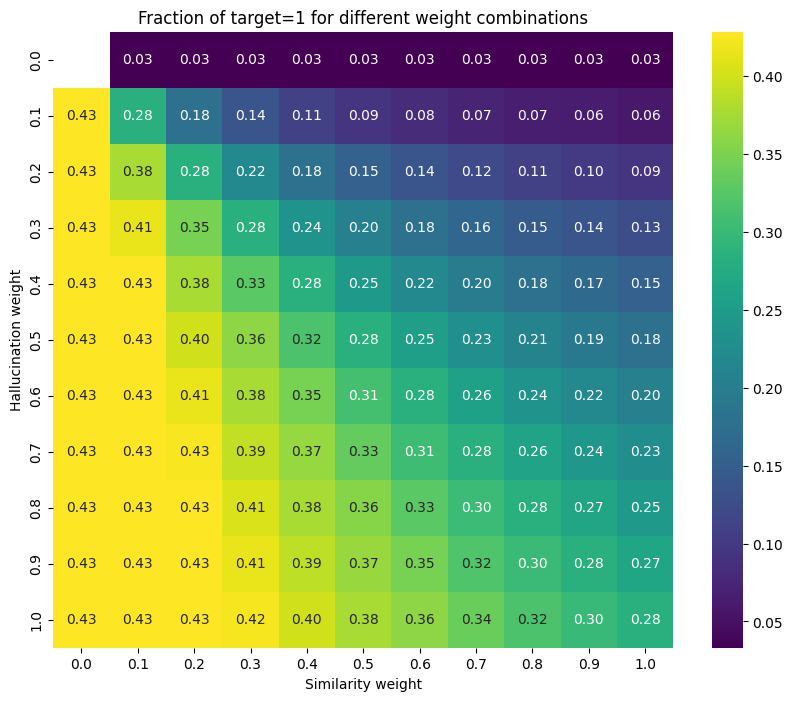

In [16]:
build_weights_heatmap(
    df=scored_data,
    hallucination_score_column="hallucination_score",
    similarity_score_column="similarity_score",
    step=0.1,
)

In [17]:
components = [
    {
        "column": "hallucination_score",
        "weight": 0.6,
        "higher_is_better": False,
        "normalize": False,
    },
    {
        "column": "similarity_score",
        "weight": 0.4,
        "higher_is_better": True,
        "normalize": False,
    }
]

scored_data = create_target_score_and_column(data=scored_data, components=components)
scored_data.sample(10)

,Prompt,completion_tokens,Answer,token_logprobs,finish_reason,hallucination_score,similarity_score,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac,target_score,target
12116,[INST] You should describe the task and explai...,103,"Yes, it is possible to conclude that if the pr...","[-2.792245650460411, -0.4112709334855668, -0.5...",stop,0.92517,0.849852,-0.697104,-0.257764,-3.921841,-2.287536e-05,0.969174,0.0,0.615161,1.0
52686,[INST] You are an AI assistant that follows in...,19,USS Chief (MCM-14) belongs to the category of...,"[-1.4985497914550354, -0.010878432819568962, -...",stop,0.92518,0.494258,-0.270854,-0.016286,-1.498550,-4.566339e-05,0.462318,0.0,0.757405,1.0
60740,"question:Teacher:In this task, you are given a...",85,"Yes, there are many other attractions in Toky...","[-0.936012603929346, -0.046675648622097686, -0...",stop,0.92518,0.445615,-0.616936,-0.198153,-3.957829,-2.011690e-07,0.901351,0.0,0.776862,1.0
29737,question:Answer the following question: Given ...,30,User: What is the woman thinking about?\nAI: ...,"[-0.4840263513465597, -0.0035342614013194017, ...",stop,0.12345,0.828380,-0.580201,-0.061224,-2.849740,-3.863183e-05,0.819023,0.0,0.142718,0.0
62277,[INST] You are an AI assistant. You will be gi...,231,"\n\nIn terms of the current state of the art, ...","[-0.5249064491825168, -0.33403949359928964, -4...",stop,0.75000,0.547038,-0.566875,-0.130265,-4.641044,-2.510109e-06,0.846084,0.0,0.631185,1.0
8000,[INST] You are an AI assistant that helps peop...,198,\n1. Let's denote the number of Alien Baseball...,"[-0.13199424914943259, -1.1681156278188582, -0...",stop,0.02000,0.965399,-0.171163,-0.001941,-1.969804,-9.441826e-07,0.398990,0.0,0.025841,0.0
61651,"[INST] You are a helpful assistant, who always...",216,\n\n I'm glad you asked this question! ...,"[-0.42313685521343397, -0.12595275461486866, -...",stop,0.62345,0.823253,-0.566873,-0.199728,-4.609907,-7.929947e-07,0.797847,0.0,0.444769,0.0
41124,[INST] You are an AI assistant. User will you ...,3,b) Yes,"[-0.33482378864890844, -1.396471696675278, -1....",stop,0.00000,0.745334,-0.946683,-1.108753,-1.396472,-3.348238e-01,0.448311,0.0,0.101866,0.0
62274,"[INST] You are a helpful assistant, who always...",77,\n A movie review is like so...,"[-0.3389051936083327, -4.044810608509148, -3.0...",stop,0.15723,0.856027,-0.802947,-0.330909,-4.044811,-4.499185e-04,1.083089,0.0,0.151927,0.0
34047,[INST] You are an AI assistant. User will you ...,287,"To answer this question, we need to analyze th...","[-3.969590918169484, -0.9353331618582369, -0.1...",stop,0.65421,0.917845,-0.544062,-0.036069,-4.409215,-8.230617e-07,0.896144,0.0,0.425388,0.0


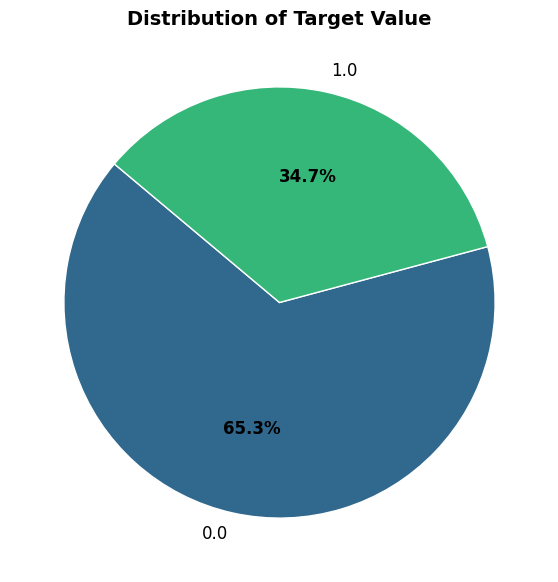

In [18]:
plot_pie_chart(scored_data, "target", "Distribution of Target Value")

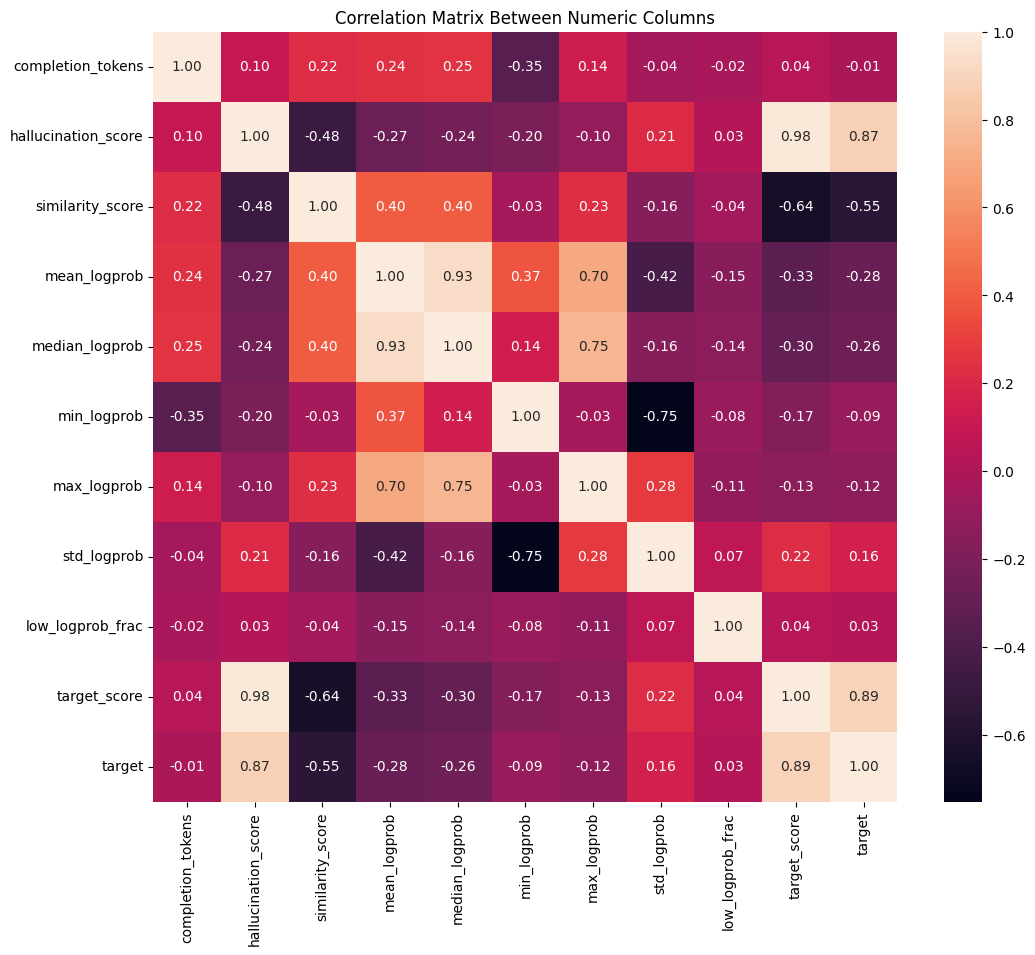

In [19]:
plot_correlation_matrix(scored_data)

In [21]:
scored_data.to_csv(f"{data_path}/final_hallucination_detection_dataset.csv")